<a href="https://colab.research.google.com/github/iking919/Detecting_Financial_Fraud_via_GNNs/blob/overhaul/04_GraphSAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GraphSAGE Modeling

### Data Extraction
First, we mount Google Drive to access our dataset and extract the processed graph data from a ZIP archive so we can use it locally in the Colab instance.

In [ ]:
from google.colab import drive
import zipfile

# mount drive
drive.mount('/content/drive')

drive_path = '/content/drive/MyDrive/GNN_fraud_Project/processed_data.zip'
extract_path = '/content'

# unzip the processed data locally to speed things up
with zipfile.ZipFile(drive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Data Inspection
We load and inspect the first few rows of the extracted CSV files to ensure all data was extracted correctly.

In [ ]:
import os
import pandas as pd

extract_path = '/content/data/processed'
csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]

for file in csv_files:
    file_path = os.path.join(extract_path, file)

    # Read just the first few rows to quickly inspect columns and types
    df = pd.read_csv(file_path, nrows=5)
    print(f"\n{'='*40}\nDataset: {file}\n{'='*40}")
    print(f"Number of features: {len(df.columns)}")
    print("Features:", list(df.columns))
    display(df.head(2))


Dataset: paysim_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,3359372,3699311
1,279050,4982860



Dataset: paysim_nodes.csv
Number of features: 9
Features: ['log_amount', 'type_encoded', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step', 'tx_id', 'label']


,log_amount,type_encoded,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step,tx_id,label
0,-0.907462,0.952399,-0.229810,-0.237622,-0.323814,-0.333411,-1.703042,2129,0
1,-1.824023,0.952399,-0.281359,-0.285812,-0.323814,-0.333411,-1.703042,2119,0



Dataset: ieee_train_nodes.csv
Number of features: 433
Features: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '

...

,0,1,2,3,4,5,6,7,8,9,...,422,423,424,425,426,427,428,429,430,431
0,-1.792644,-0.418162,0.591741,0.092483,-1.606985,-0.283858,0.691996,0.632954,0.526399,-1.288871,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874
1,-1.792635,-0.348790,0.591741,-1.163822,-1.606985,-0.283858,0.691996,0.632954,0.526399,0.065373,...,0.544145,-0.199723,0.37658,0.407556,0.565944,0.605893,0.564739,0.579979,0.569268,0.341874



Dataset: elliptic_nodes.csv
Number of features: 168
Features: ['timestep', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_40', 'feature_41', 'feature_42', 'feature_43', 'feature_44', 'feature_45', 'feature_46', 'feature_47', 'feature_48', 'feature_49', 'feature_50', 'feature_51', 'feature_52', 'feature_53', 'feature_54', 'feature_55', 'feature_56', 'feature_57', 'feature_58', 'feature_59', 'feature_60', 'feature_61', 'feature_62', 'feature_63', 'feature_64', 'feature_65', 'feature_66', 'feature_

,timestep,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,tx_id,label
0,-1.556878,0.307025,1.168821,-0.748109,7.643807,-0.053406,6.039024,21.528480,-0.146334,-0.084347,...,0.155526,0.155844,2.115930,0.016322,-0.117599,0.593442,-0.08332,-0.082052,232438397,0
1,-1.556878,0.067780,0.271911,-0.226081,2.628539,-0.053406,2.820415,1.501088,-0.146334,-0.127352,...,0.155526,0.155844,1.200416,-0.028141,-0.117599,0.270020,-0.08332,-0.082052,232029206,0



Dataset: elliptic_edges.csv
Number of features: 2
Features: ['source', 'target']


,source,target
0,230425980,5530458
1,232022460,232438397


### Environment Setup
We need to install the `torch_geometric` library, which provides the necessary modules for building and training our Graph Neural Networks.

In [ ]:
# Install torch_geometric and its sampling dependencies
!pip install torch_geometric

import torch
# Get the PyTorch version and CUDA version to find the matching wheels
PYT = torch.__version__.split('+')[0]
CUDA = 'cu' + torch.version.cuda.replace('.', '')

# Install the necessary extensions for NeighborLoader/Sampling
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-{PYT}+{CUDA}.html

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 212.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 217.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 221.4 MB/s eta 0:00:00


### Library Imports and Seed Initialization
Here we import necessary libraries such as PyTorch, PyTorch Geometric, Pandas, and Scikit-Learn. We also set universal random seeds across NumPy and PyTorch to ensure our experiments are reproducible.

In [ ]:
import random
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# Set seed for reproducibility
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    # Force deterministic algorithms in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Use deterministic implementation for scatter operations if available
    torch.use_deterministic_algorithms(True, warn_only=True)

print(f"Universal seed set to: {seed} with strict deterministic mode.")

Universal seed set to: 42 with strict deterministic mode.


## Load Graph Data

We load the graph data for the PaySim and Elliptic Dataset, creating the train, test and validation splits

In [ ]:
from sklearn.metrics import average_precision_score

def load_graph_data(nodes_path, edges_path, label_col="label"):
    #Loads node and edge CSV files into a PyG Data object for binary classification.
    print(f"Loading data from {nodes_path}...")

    nodes_df = pd.read_csv(nodes_path)
    edges_df = pd.read_csv(edges_path)

    nodes_df.fillna(0, inplace=True)

    # Generate ID mapping for continuous indexing
    mapping = {nid: i for i, nid in enumerate(nodes_df["tx_id"].values)}

    edges_df["source"] = edges_df["source"].map(mapping)
    edges_df["target"] = edges_df["target"].map(mapping)
    edges_df.dropna(subset=["source", "target"], inplace=True)

    edges_df["source"] = edges_df["source"].astype(int)
    edges_df["target"] = edges_df["target"].astype(int)

    # Select features excluding metadata and labels
    feature_cols = [
        c for c in nodes_df.columns
        if c not in [label_col, "tx_id", "timestep", "source", "target"]
    ]

    x = torch.tensor(nodes_df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(nodes_df[label_col].values, dtype=torch.float32)

    edge_index = torch.tensor(
        edges_df[["source", "target"]].values.T,
        dtype=torch.long
    )

    idx = np.arange(len(nodes_df))

    # Perform stratified split to maintain class balance
    train_idx, test_idx = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=nodes_df[label_col]
    )

    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=0.25,
        random_state=42,
        stratify=nodes_df[label_col].iloc[train_idx]
    )

    data = Data(x=x, edge_index=edge_index, y=y)

    # Assign boolean masks for split indexing
    data.train_mask = torch.zeros(len(nodes_df), dtype=torch.bool)
    data.val_mask = torch.zeros(len(nodes_df), dtype=torch.bool)
    data.test_mask = torch.zeros(len(nodes_df), dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True

    print(f"Data loaded: {data.num_nodes} nodes, {data.num_edges} edges.")
    return data, nodes_df

The ieee data is different, since it already has test data separate, therefore we just create the validation split.

In [ ]:
def load_ieee_split_data(
    train_nodes_path,
    train_edges_path,
    test_nodes_path,
    test_edges_path,
    label_col="label"
):
    print("Loading IEEE-CIS dataset...")

    train_nodes = pd.read_csv(train_nodes_path)
    test_nodes = pd.read_csv(test_nodes_path)

    train_edges = pd.read_csv(train_edges_path)
    test_edges = pd.read_csv(test_edges_path)

    # ensure tx_id exists
    if "tx_id" not in train_nodes.columns:
        train_nodes["tx_id"] = np.arange(len(train_nodes))
    if "tx_id" not in test_nodes.columns:
        test_nodes["tx_id"] = np.arange(len(test_nodes)) + len(train_nodes)

    # combine nodes
    all_nodes = pd.concat([train_nodes, test_nodes], ignore_index=True)

    # handle labels properly
    y_raw = all_nodes[label_col].values.astype(float)
    label_mask = ~np.isnan(y_raw)

    y_raw[np.isnan(y_raw)] = 0.0  # placeholder

    # features
    feature_cols = [
        c for c in all_nodes.columns
        if c not in [label_col, "tx_id", "timestep"]
    ]

    X = all_nodes[feature_cols].values.astype(np.float32)

    # replace inf/nan in features
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # edge mapping
    mapping = {nid: i for i, nid in enumerate(all_nodes["tx_id"].values)}

    def map_edges(df):
        df = df.copy()
        df["source"] = df["source"].map(mapping)
        df["target"] = df["target"].map(mapping)
        df = df.dropna(subset=["source", "target"])
        return df.astype(int)

    all_edges = pd.concat([map_edges(train_edges), map_edges(test_edges)])

    edge_index = torch.tensor(
        all_edges[["source", "target"]].values.T,
        dtype=torch.long
    )

    # tensors
    x = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y_raw, dtype=torch.float32)
    label_mask = torch.tensor(label_mask, dtype=torch.bool)

    # masks
    train_size = len(train_nodes)
    labeled_idx = np.arange(train_size)

    # Split the LABELED data into 60% train, 20% val, 20% test
    train_idx, test_idx = train_test_split(
        labeled_idx,
        test_size=0.2,
        random_state=42,
        stratify=train_nodes[label_col].fillna(0)
    )

    train_idx, val_idx = train_test_split(
        train_idx,
        test_size=0.25, # 0.25 * 0.8 = 0.2
        random_state=42,
        stratify=train_nodes[label_col].iloc[train_idx].fillna(0)
    )

    data = Data(x=x, edge_index=edge_index, y=y)

    data.train_mask = torch.zeros(len(all_nodes), dtype=torch.bool)
    data.val_mask = torch.zeros(len(all_nodes), dtype=torch.bool)
    data.test_mask = torch.zeros(len(all_nodes), dtype=torch.bool)
    data.label_mask = label_mask

    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True

    print(f"Nodes: {data.num_nodes}")
    print(f"Labeled nodes: {label_mask.sum().item()}")

    return data

## GraphSAGE Model Implementation
We define a standard 2-layer GraphSAGE architecture using Mean Aggregation. This model leverages neighborhood information to generate node embeddings suitable for fraud detection tasks.

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    #Two-layer GraphSAGE implementation for node classification.
    def __init__(self, in_channels, hidden_channels=128, out_channels=1, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # First convolution with ReLU and Dropout
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # Output layer
        x = self.conv2(x, edge_index)
        return x

## Baseline Training
This section implements full-batch training logic. It processes the entire graph at once, which is suitable for medium-sized datasets and provides a stable performance baseline using class-weighted Binary Cross Entropy loss.

In [ ]:
def train_full_batch(
    model,
    data,
    device,
    epochs=200,
    lr=0.003,
    clip_grad=1.0
):
    model.to(device)
    data = data.to(device)

    # calculate pos_weight
    pos_weight = (
        (data.y[data.train_mask] == 0).sum() /
        (data.y[data.train_mask] == 1).sum().clamp(min=1)
    ).to(device)

    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data.x, data.edge_index).squeeze()

        # stability fix
        out = torch.tanh(out) * 5

        loss = criterion(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()

        # Reduced output verbosity
        if epoch == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

    return model

## Mini-Batch GraphSAGE Implementation
To handle larger graphs and improve convergence on imbalanced data, we implement a Mini-Batch approach using `NeighborLoader`. This section also introduces Focal Loss to focus the model's attention on difficult fraud cases.

In [ ]:
from torch_geometric.loader import NeighborLoader, ImbalancedSampler

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.to(logits.dtype) # Cast targets back to float for BCE
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none"
        )

        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)

        weight = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        loss = weight * (1 - pt).pow(self.gamma) * bce
        return loss.mean()


def train_minibatch(
    model,
    data,
    device,
    alpha=0.85,
    epochs=100,
    lr=0.003
):
    model.to(device)
    data = data.to(device)

    criterion = FocalLoss(alpha=alpha)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    # Use ImbalancedSampler to oversample the minority class
    train_sampler = ImbalancedSampler(data, input_nodes=data.train_mask)

    train_loader = NeighborLoader(
        data,
        num_neighbors=[10, 10],
        batch_size=1024,
        input_nodes=data.train_mask,
        sampler=train_sampler
    )

    val_loader = NeighborLoader(
        data,
        num_neighbors=[10, 10],
        batch_size=1024,
        input_nodes=data.val_mask,
    )

    best_val = float("inf")
    best_state = None
    patience, counter = 10, 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()

            out = model(batch.x, batch.edge_index).squeeze()

            # seed handling (PyG guarantees first batch_size are seeds)
            out = out[:batch.batch_size]
            y = batch.y[:batch.batch_size]

            loss = criterion(out, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()

        # validation
        model.eval()
        val_loss = 0
        n = 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)

                out = model(batch.x, batch.edge_index).squeeze()

                out = out[:batch.batch_size]
                y = batch.y[:batch.batch_size]

                val_loss += criterion(out, y).item()
                n += 1

        val_loss /= max(n, 1)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | train {total_loss:.4f} | val {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model


## Hyperparameter Search
We perform a grid search over key parameters such as learning rate, hidden layer size, and dropout. This block also includes automated threshold optimization to maximize the F1-score for the fraud class.

In [ ]:
def hyperparameter_search(
    model_cls,
    data,
    device,
    search_space,
    mode="full"
):
    import copy

    best_f1 = 0
    best_cfg = None
    best_model = None

    threshold_grid = np.linspace(0.01, 0.99, 50)

    # Iterate through all parameters in the expanded search space
    for lr in search_space["lr"]:
        for pw in search_space["pos_weight"]:
            for alpha in search_space["alpha"]:
                for hidden in search_space["hidden"]:
                    for dropout in search_space["dropout"]:

                        print(f"\n--- lr={lr}, hidden={hidden}, dropout={dropout} ---")

                        # Initialize model with current hyperparams
                        model = model_cls(
                            in_channels=data.num_features,
                            hidden_channels=hidden,
                            out_channels=1,
                            dropout=dropout
                        )

                        # train models
                        if mode == "full":
                            model = train_full_batch(
                                model,
                                data,
                                device=device,
                                lr=lr
                            )
                        else:
                            model = train_minibatch(
                                model,
                                data,
                                device=device,
                                alpha=alpha,
                                lr=lr
                            )

                        # validation
                        model.eval()
                        with torch.no_grad():
                            out = model(
                                data.x.to(device),
                                data.edge_index.to(device)
                            ).squeeze()

                            probs = torch.sigmoid(out[data.val_mask]).cpu().numpy()
                            y = data.y[data.val_mask].cpu().numpy()

                        # ===== THRESHOLD SEARCH =====
                        best_local_f1 = 0
                        best_t = 0.5

                        for t in threshold_grid:
                            preds = (probs > t).astype(int)
                            f1 = f1_score(y, preds, zero_division=0)

                            if f1 > best_local_f1:
                                best_local_f1 = f1
                                best_t = t

                        print(f"Val F1: {best_local_f1:.4f} | Best threshold: {best_t:.2f}")

                        # ===== TRACK BEST CONFIG =====
                        if best_local_f1 > best_f1:
                            best_f1 = best_local_f1
                            best_cfg = {
                                "lr": lr,
                                "pos_weight": pw,
                                "alpha": alpha,
                                "hidden": hidden,
                                "dropout": dropout,
                                "threshold": best_t
                            }
                            best_model = copy.deepcopy(model).cpu()

    print("\n================ BEST CONFIG ================")
    print(best_cfg)
    print(f"Best F1: {best_f1:.4f}")

    return best_model, best_cfg

## Final Model Evaluation
We evaluate the best-tuned model on the test set to report final performance metrics.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, average_precision_score

def evaluate_final_model(model, data, config, device, model_name="GraphSAGE"):
    model.to(device)
    model.eval()

    with torch.no_grad():
        out = model(data.x.to(device), data.edge_index.to(device)).squeeze()
        probs = torch.sigmoid(out[data.test_mask]).cpu().numpy()
        y_true = data.y[data.test_mask].cpu().numpy()

    # Use the threshold found during tuning
    threshold = config.get('threshold', 0.5)
    preds = (probs > threshold).astype(int)

    # Calculate metrics
    auc_roc = roc_auc_score(y_true, probs)
    auc_pr = average_precision_score(y_true, probs)

    # Focus on the fraud class (label 1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, labels=[1], average='binary', zero_division=0)

    results = {
        "Model": model_name,
        "AUC-PR": f"{auc_pr:.4f}",
        "AUC-ROC": f"{auc_roc:.4f}",
        "F1 (Fraud)": f"{f1:.4f}",
        "Recall (Fraud)": f"{recall:.4f}",
        "Precision (Fraud)": f"{precision:.4f}"
    }

    return results


## Dataset Tuning: PaySim, Elliptic, and IEEE-CIS
We train our models using all three datasets. As mentioned, we handle the IEEE-CIS dataset uniquely since it provides separate training and testing files.

###First we define our device configuration, and parameter search space

In [ ]:
import torch

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Expanded Search Space for GraphSAGE
search_space = {
    'lr': [0.001, 0.0005],
    'pos_weight': [5, 10],
    'alpha': [0.85, 0.9],
    'hidden': [64, 128, 256],
    'dropout': [0.3, 0.5],
    'num_layers': [2, 3]
}

print(f"Running on device: {device}")
print("Search space initialized for all datasets.")

Running on device: cuda
Search space initialized for all datasets.


### 1. PaySim Dataset Tuning

In [ ]:
print(f"\nProcessing Paysim Dataset")

paysim_data, _ = load_graph_data(
    "/content/data/processed/paysim_nodes.csv",
    "/content/data/processed/paysim_edges.csv",
    "label"
)

# Run Search
best_model_paysim, best_cfg_paysim = hyperparameter_search(
    GraphSAGE, paysim_data, device, search_space, mode="full"
)


In [ ]:
# Final Eval
paysim_metrics = evaluate_final_model(best_model_paysim, paysim_data, best_cfg_paysim, device, "PaySim GraphSAGE")
display(pd.DataFrame([paysim_metrics]))

,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,PaySim GraphSAGE,0.4884,0.9698,0.5118,0.4029,0.7013


### 2. Elliptic Dataset Tuning

In [ ]:
print(f"\nProcessing Elliptic Dataset")

elliptic_data, _ = load_graph_data(
    "/content/data/processed/elliptic_nodes.csv",
    "/content/data/processed/elliptic_edges.csv",
    "label"
)

# Run Search
best_model_elliptic, best_cfg_elliptic = hyperparameter_search(
    GraphSAGE, elliptic_data, device, search_space, mode="full"
)


In [ ]:
# Final Eval
elliptic_metrics = evaluate_final_model(best_model_elliptic, elliptic_data, best_cfg_elliptic, device, "Elliptic GraphSAGE")
display(pd.DataFrame([elliptic_metrics]))

,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,Elliptic GraphSAGE,0.9251,0.9797,0.8743,0.8339,0.9188


### 3. IEEE-CIS Dataset Tuning

*Note: Due to the massive size of the IEEE-CIS dataset, we use a significantly narrowed search space here to reduce training time.*

In [ ]:
print(f"\nProcessing IEEE-CIS Dataset with Narrow Search Space")

ieee_data = load_ieee_split_data(
    "/content/data/processed/ieee_train_nodes.csv",
    "/content/data/processed/ieee_train_edges.csv",
    "/content/data/processed/ieee_test_nodes.csv",
    "/content/data/processed/ieee_test_edges.csv"
)

narrow_search_space = {
    'lr': [0.001],
    'pos_weight': [10],
    'alpha': [0.85],
    'hidden': [128, 256],
    'dropout': [0.5]
}

# Run Search using the narrow space
best_model_ieee, best_cfg_ieee = hyperparameter_search(
    GraphSAGE, ieee_data, device, narrow_search_space, mode="full"
)

Our last call uses an incorrect testing function. Rather than training our model all over, we correct the testing function and evaluate it again.



In [ ]:
# Final Eval
ieee_metrics = evaluate_final_model(best_model_ieee, ieee_data, best_cfg_ieee, device, "IEEE-CIS GCN")
display(pd.DataFrame([ieee_metrics]))

,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,IEEE-CIS GCN,0.5603,0.9146,0.5571,0.4583,0.7104


## Mini-Batch GraphSAGE Evaluation
In this section, we train our models using the **Mini-Batch** (NeighborLoader) approach across all three datasets. To save time and resources, we skip the hyperparameter search here and directly utilize the best hyperparameters discovered during the full-batch tuning phase.

### Handling Class Imbalance
This implementation is specifically designed to handle class imbalance more effectively than the standard approach by:
1. **Focal Loss**: Using a custom Focal Loss implementation that applies a modulating factor to the cross-entropy loss, focusing the learning on hard-to-classify 'fraud' instances.
2. **Alpha Parameter**: Incorporating the optimal `alpha` value found during the full-batch search to properly weight the focal loss mechanism.

### 1. PaySim Mini-Batch Tuning

In [ ]:
print(f"\nProcessing Paysim (Mini-Batch)")

paysim_data, _ = load_graph_data(
    "/content/data/processed/paysim_nodes.csv",
    "/content/data/processed/paysim_edges.csv",
    "label"
)

# Fix: ImbalancedSampler requires labels to be integer types to compute class weights
paysim_data.y = paysim_data.y.to(torch.long)

# Hardcoded best parameters from full-batch tuning
best_cfg_paysim_mini = {
    'lr': 0.001,
    'pos_weight': 10,
    'alpha': 0.9,
    'hidden': 256,
    'dropout': 0.3,
    'threshold': 0.69
}
print(f"Using parameters: {best_cfg_paysim_mini}")

# Initialize model
model_paysim_mini = GraphSAGE(
    in_channels=paysim_data.num_features,
    hidden_channels=best_cfg_paysim_mini['hidden'],
    out_channels=1,
    dropout=best_cfg_paysim_mini['dropout']
)

# Train in mini-batch mode
best_model_paysim_mini = train_minibatch(
    model_paysim_mini,
    paysim_data,
    device=device,
    alpha=best_cfg_paysim_mini.get('alpha', 0.85),
    lr=best_cfg_paysim_mini.get('lr', 0.001)
)


In [ ]:
# Final Eval
paysim_mini_metrics = evaluate_final_model(best_model_paysim_mini, paysim_data, best_cfg_paysim_mini, device, "PaySim Mini-Batch")
display(pd.DataFrame([paysim_mini_metrics]))

,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,PaySim Mini-Batch,0.4644,0.9833,0.0507,0.8764,0.0261


### 2. Elliptic Mini-Batch Tuning

In [ ]:
print(f"\nProcessing Elliptic (Mini-Batch)")

elliptic_data, _ = load_graph_data(
    "/content/data/processed/elliptic_nodes.csv",
    "/content/data/processed/elliptic_edges.csv",
    "label"
)


elliptic_data.y = elliptic_data.y.to(torch.long)

# Hardcoded best parameters from full-batch tuning
best_cfg_elliptic_mini = {
    'lr': 0.001,
    'pos_weight': 10,
    'alpha': 0.9,
    'hidden': 256,
    'dropout': 0.3,
    'threshold': 0.59
}
print(f"Using parameters: {best_cfg_elliptic_mini}")

# Initialize model
model_elliptic_mini = GraphSAGE(
    in_channels=elliptic_data.num_features,
    hidden_channels=best_cfg_elliptic_mini['hidden'],
    out_channels=1,
    dropout=best_cfg_elliptic_mini['dropout']
)

# Train in mini-batch mode
best_model_elliptic_mini = train_minibatch(
    model_elliptic_mini,
    elliptic_data,
    device=device,
    alpha=best_cfg_elliptic_mini.get('alpha', 0.85),
    lr=best_cfg_elliptic_mini.get('lr', 0.001)
)


In [ ]:
# Final Eval
elliptic_mini_metrics = evaluate_final_model(best_model_elliptic_mini, elliptic_data, best_cfg_elliptic_mini, device, "Elliptic Mini-Batch")
display(pd.DataFrame([elliptic_mini_metrics]))


,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,Elliptic Mini-Batch,0.9172,0.9812,0.6322,0.9483,0.4741


### 3. IEEE-CIS Mini-Batch Evaluation

In [ ]:
print(f"\nProcessing IEEE-CIS (Mini-Batch)")

ieee_data = load_ieee_split_data(
    "/content/data/processed/ieee_train_nodes.csv",
    "/content/data/processed/ieee_train_edges.csv",
    "/content/data/processed/ieee_test_nodes.csv",
    "/content/data/processed/ieee_test_edges.csv"
)

ieee_data.y = ieee_data.y.to(torch.long)

# Hardcoded best parameters from full-batch tuning
best_cfg_ieee_mini = {
    'lr': 0.001,
    'pos_weight': 10,
    'alpha': 0.85,
    'hidden': 256,
    'dropout': 0.5,
    'threshold': 0.61
}
print(f"Using parameters: {best_cfg_ieee_mini}")

# Initialize model
model_ieee_mini = GraphSAGE(
    in_channels=ieee_data.num_features,
    hidden_channels=best_cfg_ieee_mini['hidden'],
    out_channels=1,
    dropout=best_cfg_ieee_mini['dropout']
)

# Train in mini-batch mode
best_model_ieee_mini = train_minibatch(
    model_ieee_mini,
    ieee_data,
    device=device,
    alpha=best_cfg_ieee_mini.get('alpha', 0.85),
    lr=best_cfg_ieee_mini.get('lr', 0.001)
)


In [ ]:
# Final Eval
ieee_mini_metrics = evaluate_final_model(best_model_ieee_mini, ieee_data, best_cfg_ieee_mini, device, "IEEE-CIS Mini-Batch")
display(pd.DataFrame([ieee_mini_metrics]))

,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,IEEE-CIS Mini-Batch,0.4998,0.8992,0.1911,0.8626,0.1075


## Final Performance Visualization
In this section, we generate ROC Curves and Confusion Matrices for our 6 best-performing models (Full-batch and Mini-batch across all three datasets) to visually assess their diagnostic ability and class-wise accuracy.


Visualizing & Saving: PaySim
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/PaySim_Full_batch.pth
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/PaySim_Mini_batch.pth


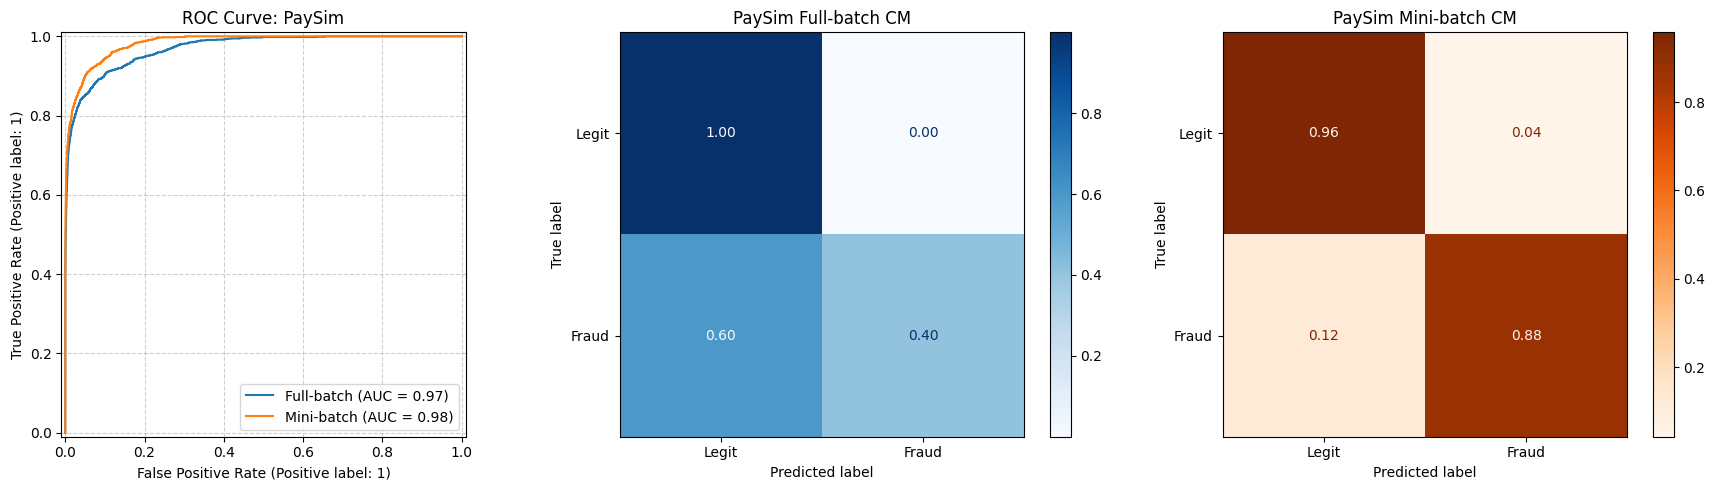


Visualizing & Saving: Elliptic
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/Elliptic_Full_batch.pth
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/Elliptic_Mini_batch.pth


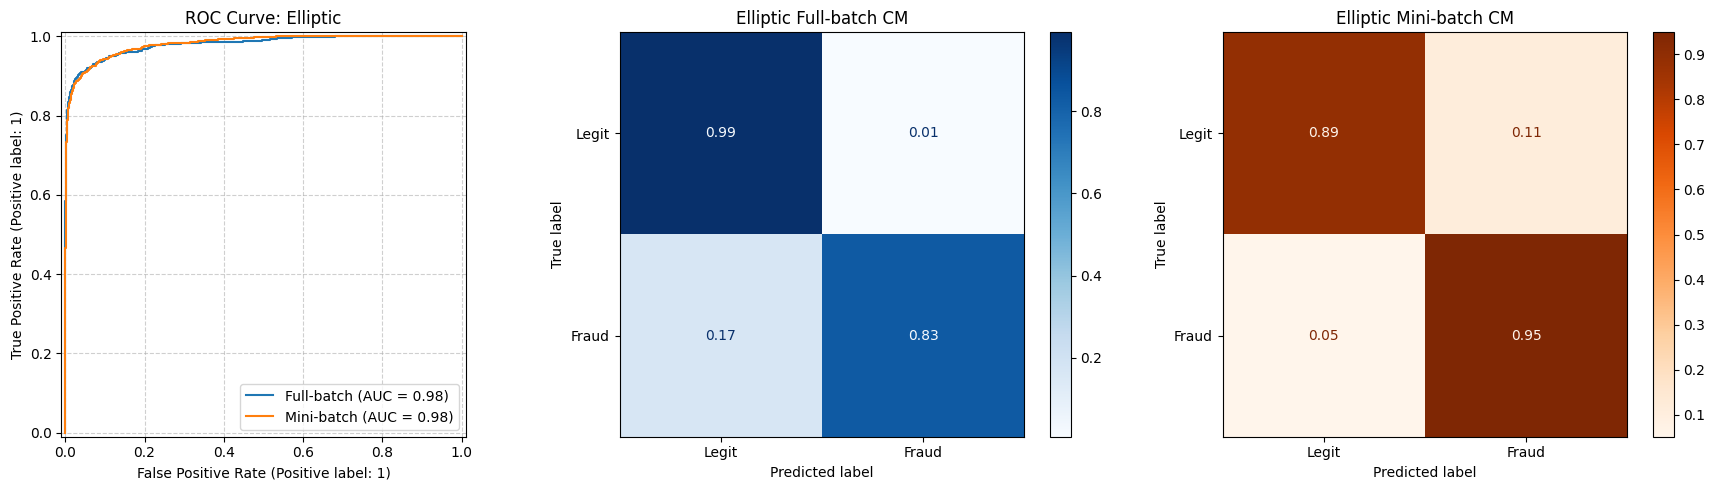


Visualizing & Saving: IEEE-CIS
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/IEEE-CIS_Full_batch.pth
Saved model state to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/IEEE-CIS_Mini_batch.pth


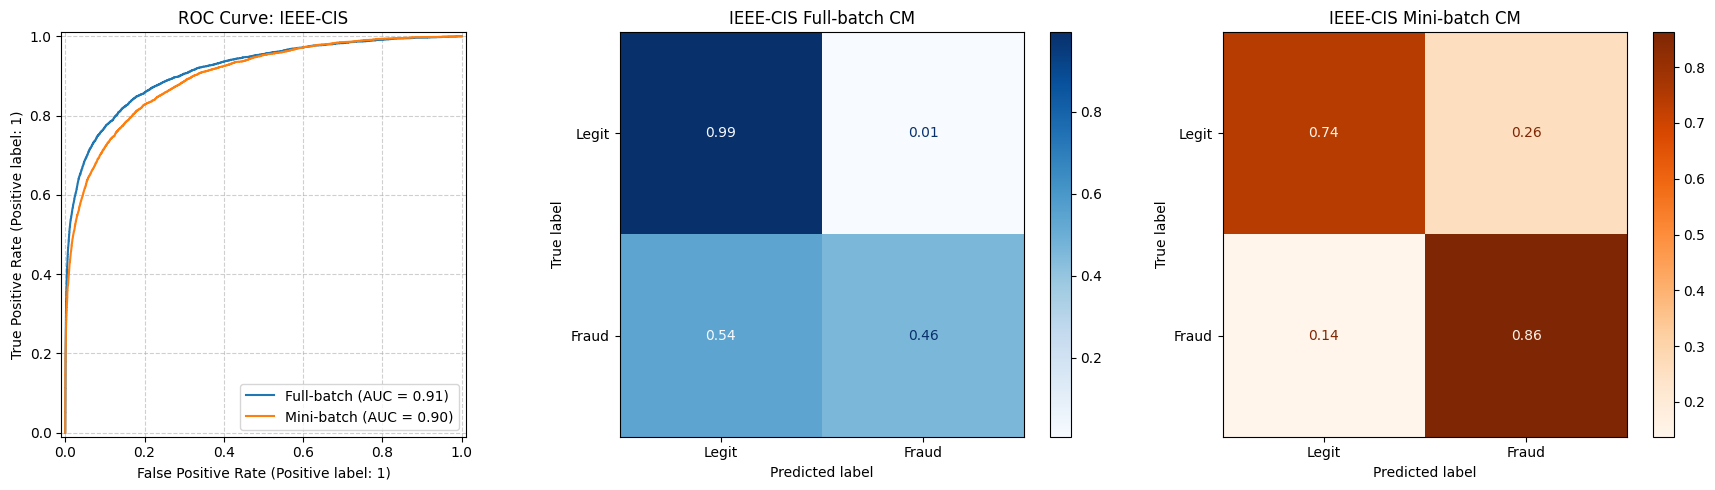


Saved comprehensive results to /content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results/comprehensive_results.pkl

FINAL PERFORMANCE SUMMARY


,Model,AUC-PR,AUC-ROC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
0,PaySim Full-batch,0.4884,0.9698,0.5118,0.4029,0.7013
1,PaySim Mini-batch,0.4644,0.9833,0.0507,0.8764,0.0261
2,Elliptic Full-batch,0.9251,0.9797,0.8743,0.8339,0.9188
3,Elliptic Mini-batch,0.9172,0.9812,0.6322,0.9483,0.4741
4,IEEE-CIS Full-batch,0.5603,0.9146,0.5571,0.4583,0.7104
5,IEEE-CIS Mini-batch,0.4998,0.8992,0.1911,0.8626,0.1075


In [ ]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import os
import pickle
import torch

# Create a directory to save models and results in Google Drive
save_dir = '/content/drive/MyDrive/GNN_fraud_Project/saved_models_and_results'
os.makedirs(save_dir, exist_ok=True)

datasets = [
    ("PaySim", "best_model_paysim", "paysim_data", "best_cfg_paysim", "best_model_paysim_mini", "best_cfg_paysim_mini"),
    ("Elliptic", "best_model_elliptic", "elliptic_data", "best_cfg_elliptic", "best_model_elliptic_mini", "best_cfg_elliptic_mini"),
    ("IEEE-CIS", "best_model_ieee", "ieee_data", "best_cfg_ieee", "best_model_ieee_mini", "best_cfg_ieee_mini")
]

all_results = []
comprehensive_results = {}

for ds_name, m_full_name, data_name, cfg_full_name, m_mini_name, cfg_mini_name in datasets:
    data = globals().get(data_name)
    if data is None:
        continue

    m_full = globals().get(m_full_name)
    cfg_full = globals().get(cfg_full_name)

    m_mini = globals().get(m_mini_name)
    cfg_mini = globals().get(cfg_mini_name)

    if m_full is None and m_mini is None:
        continue

    print(f"\n{'='*60}\nVisualizing & Saving: {ds_name}\n{'='*60}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].set_title(f"ROC Curve: {ds_name}")
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Process Full-batch
    if m_full is not None and cfg_full is not None:
        m_full.to(device)
        m_full.eval()
        with torch.no_grad():
            out = m_full(data.x.to(device), data.edge_index.to(device)).squeeze()
            probs = torch.sigmoid(out[data.test_mask]).cpu().numpy()
            y_true = data.y[data.test_mask].cpu().numpy()

        threshold = cfg_full.get('threshold', 0.5)
        y_pred = (probs > threshold).astype(int)

        metrics = evaluate_final_model(m_full, data, cfg_full, device, f"{ds_name} Full-batch")
        all_results.append(metrics)

        model_path = os.path.join(save_dir, f"{ds_name}_Full_batch.pth")
        torch.save(m_full.state_dict(), model_path)
        print(f"Saved model state to {model_path}")

        comprehensive_results[f"{ds_name} Full-batch"] = {
            'y_true': y_true, 'probs': probs, 'preds': y_pred, 'metrics': metrics, 'config': cfg_full
        }

        RocCurveDisplay.from_predictions(y_true, probs, ax=axes[0], name="Full-batch")
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Legit", "Fraud"], normalize='true', values_format=".2f", ax=axes[1], cmap='Blues')
        axes[1].set_title(f"{ds_name} Full-batch CM")
    else:
        axes[1].set_visible(False)

    # Process Mini-batch
    if m_mini is not None and cfg_mini is not None:
        m_mini.to(device)
        m_mini.eval()
        with torch.no_grad():
            out = m_mini(data.x.to(device), data.edge_index.to(device)).squeeze()
            probs = torch.sigmoid(out[data.test_mask]).cpu().numpy()
            y_true = data.y[data.test_mask].cpu().numpy()

        threshold = cfg_mini.get('threshold', 0.5)
        y_pred = (probs > threshold).astype(int)

        metrics = evaluate_final_model(m_mini, data, cfg_mini, device, f"{ds_name} Mini-batch")
        all_results.append(metrics)

        model_path = os.path.join(save_dir, f"{ds_name}_Mini_batch.pth")
        torch.save(m_mini.state_dict(), model_path)
        print(f"Saved model state to {model_path}")

        comprehensive_results[f"{ds_name} Mini-batch"] = {
            'y_true': y_true, 'probs': probs, 'preds': y_pred, 'metrics': metrics, 'config': cfg_mini
        }

        RocCurveDisplay.from_predictions(y_true, probs, ax=axes[0], name="Mini-batch")
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Legit", "Fraud"], normalize='true', values_format=".2f", ax=axes[2], cmap='Oranges')
        axes[2].set_title(f"{ds_name} Mini-batch CM")
    else:
        axes[2].set_visible(False)

    plt.tight_layout()
    plt.show()

# Save all comprehensive results into a single pickle file
results_path = os.path.join(save_dir, 'comprehensive_results.pkl')
with open(results_path, 'wb') as f:
    pickle.dump(comprehensive_results, f)
print(f"\nSaved comprehensive results to {results_path}")

# Display Final Summary Table
print(f"\n{'='*60}\nFINAL PERFORMANCE SUMMARY\n{'='*60}")
summary_df = pd.DataFrame(all_results)
display(summary_df)


## Conclusions

GraphSAGE demonstrates strong performance overall, with full-batch training consistently outperforming mini-batch training across all datasets. On PaySim, the full-batch model achieves a solid F1 score (0.51) with high precision, while the mini-batch version suffers from extremely low precision despite high recall, indicating over-prediction of fraud. On Elliptic, GraphSAGE performs exceptionally well, reaching very high F1 (0.87) in the full-batch setting and still strong performance in mini-batch mode, highlighting the advantage of graph structure in this dataset. On IEEE-CIS, full-batch GraphSAGE significantly surpasses all baseline models with an F1 of 0.56, whereas the mini-batch variant again shows unstable behavior with high recall but poor precision. Overall, these results indicate that GraphSAGE effectively leverages relational information, especially in structured datasets like Elliptic and IEEE-CIS. But that mini-batch training introduces instability and precision loss, making full-batch training the more reliable approach in this setting.